# Notebook 05 -- Baseline Models

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland

**Author:** Diego Marrero Ferrera  
**Repository:** [GitHub -- Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  
**Last updated:** 2026-04

---

### Purpose

This notebook implements the **classical baseline models** against which the more complex ML and deep learning approaches (Notebooks 06-07) will be compared. The baselines establish a performance floor: any model that cannot beat these simple approaches is not worth the added complexity.

The models implemented are:

1. **Naive Seasonal**: repeats the value from the same month of the previous year. The simplest possible seasonal forecast and a surprisingly difficult benchmark to beat (Athanasopoulos et al., 2011).
2. **Holt-Winters** (triple exponential smoothing): captures level, trend, and multiplicative seasonality with exponentially decaying weights.
3. **SARIMA**: Seasonal ARIMA, the standard Box-Jenkins approach with seasonal differencing.
4. **SARIMAX**: SARIMA extended with exogenous variables (HICP ratio, GDP, CCI, lagged seats), testing whether adding economic predictors improves upon the purely univariate SARIMA.
5. **BSTS** (Bayesian Structural Time Series): a Bayesian decomposition into trend + seasonality + regression, with automatic variable selection via spike-and-slab priors. This produces posterior credibility intervals rather than point forecasts.

All models are evaluated on the same **hold-out test set** (last 12 months of data) using RMSE, MAE, and MAPE. Additionally, following tutor guidance, we compare model performance when trained on the **full sample** (with COVID dummies) versus **pre-COVID data only** (2011-2019), to assess whether the pandemic introduced a structural break that distorts the estimated relationships.

---

## 0. Environment & Configuration

In [26]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- PLOT SETTINGS ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'savefig.bbox': 'tight',
    'savefig.dpi': 200,
    'savefig.facecolor': 'white',
})

COLORS = {
    'primary': '#2c3e50', 'secondary': '#e74c3c',
    'accent1': '#3498db', 'accent2': '#2ecc71',
    'accent3': '#f39c12', 'accent4': '#9b59b6',
    'gray': '#95a5a6',
}

COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-06-30')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PROCESSED = os.path.join('..', 'data', 'processed')
FIGURES = os.path.join('..', 'figures', 'models')
os.makedirs(FIGURES, exist_ok=True)


def savefig(name):
    plt.savefig(os.path.join(FIGURES, name))


print('Environment ready.')

Environment ready.


---

## 1. Load Master Panel & Define Train/Test Split

We load the master panel exported by Notebook 04 and define a consistent train/test split that will be used across all modelling notebooks (05-08). The **last 12 months** of data are held out as the test set, matching the standard evaluation horizon in the tourism forecasting literature (Athanasopoulos et al., 2011).

In [27]:
# --- LOAD MASTER PANEL ---
panel = pd.read_csv(
    os.path.join(DATA_PROCESSED, 'master_panel_monthly.csv'),
    index_col=0, parse_dates=True
)
panel.index.name = 'date'

print(f'Panel: {panel.shape[0]} rows x {panel.shape[1]} columns')
print(f'Period: {panel.index[0]:%Y-%m} -> {panel.index[-1]:%Y-%m}')

Panel: 179 rows x 39 columns
Period: 2011-01 -> 2025-11


In [28]:
# --- TRAIN / TEST SPLIT ---
TEST_MONTHS = 12

# Target series (drop any leading NaN from lagged features)
y_full = panel['nights'].dropna()

split_date = y_full.index[-TEST_MONTHS]
y_train = y_full[y_full.index < split_date]
y_test  = y_full[y_full.index >= split_date]

# Also define a pre-COVID training set for robustness comparison
y_train_precovid = y_train[y_train.index < '2020-01-01']

print(f'Full series:   {len(y_full)} months ({y_full.index[0]:%Y-%m} -> {y_full.index[-1]:%Y-%m})')
print(f'Training set:  {len(y_train)} months ({y_train.index[0]:%Y-%m} -> {y_train.index[-1]:%Y-%m})')
print(f'Test set:      {len(y_test)} months ({y_test.index[0]:%Y-%m} -> {y_test.index[-1]:%Y-%m})')
print(f'Pre-COVID set: {len(y_train_precovid)} months ({y_train_precovid.index[0]:%Y-%m} -> {y_train_precovid.index[-1]:%Y-%m})')

Full series:   179 months (2011-01 -> 2025-11)
Training set:  167 months (2011-01 -> 2024-11)
Test set:      12 months (2024-12 -> 2025-11)
Pre-COVID set: 108 months (2011-01 -> 2019-12)


---

## 2. Evaluation Metrics

We define a consistent set of evaluation functions that will be reused across all modelling notebooks. The three standard metrics are RMSE (penalises large errors), MAE (robust to outliers), and MAPE (percentage-based, intuitive). We also store all results in a single DataFrame for the final comparison.

In [29]:
def compute_metrics(y_true, y_pred, model_name='Model'):
    """
    Compute RMSE, MAE, and MAPE between actual and predicted values.
    Returns a dictionary ready for appending to the results table.
    """
    # Align and drop NaN
    valid = pd.DataFrame({'true': y_true, 'pred': y_pred}).dropna()
    if len(valid) == 0:
        return {'Model': model_name, 'RMSE': np.nan, 'MAE': np.nan, 'MAPE': np.nan}

    y_t = valid['true'].values
    y_p = valid['pred'].values

    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    # MAPE: avoid division by zero
    mask = y_t != 0
    mape = np.mean(np.abs((y_t[mask] - y_p[mask]) / y_t[mask])) * 100

    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


def plot_forecast(y_train, y_test, y_pred, title='Forecast', ci_lower=None, ci_upper=None):
    """
    Plot the training data, test data, and forecast with optional confidence interval.
    Only shows the last 36 months of training for readability.
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    # Show last 36 months of training for context
    train_tail = y_train.iloc[-36:]
    ax.plot(train_tail.index, train_tail.values,
            color=COLORS['primary'], label='Training (last 3 years)')
    ax.plot(y_test.index, y_test.values,
            color=COLORS['secondary'], label='Actual (test)', lw=2.5)
    ax.plot(y_pred.index, y_pred.values,
            color=COLORS['accent1'], label='Forecast', ls='--', lw=2)

    if ci_lower is not None and ci_upper is not None:
        ax.fill_between(y_pred.index, ci_lower, ci_upper,
                        color=COLORS['accent1'], alpha=0.15, label='95% CI')

    ax.axvline(y_test.index[0], color=COLORS['gray'], ls=':', lw=1)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Overnight stays')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(loc='upper left')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig, ax


# Store all results here
all_results = []
all_forecasts = {}  # model_name -> forecast Series

print('Evaluation functions defined.')

Evaluation functions defined.


---

## 3. Model 1: Naive Seasonal Baseline

The simplest seasonal forecast: predict each month as the value from the **same month of the previous year**. Despite its simplicity, the tourism forecasting competition of Athanasopoulos et al. (2011) showed that this benchmark is remarkably hard to beat, especially at short horizons. Any model that cannot outperform this baseline is adding complexity without value.

In [30]:
# --- NAIVE SEASONAL: y_hat(t) = y(t-12) ---
naive_pred = y_train.shift(12).reindex(y_test.index)

# If any test month doesn't have a value 12 months prior in training, use the
# last available same-month value from the full series
for i, date in enumerate(y_test.index):
    if pd.isna(naive_pred.iloc[i]):
        same_month_prev = y_full[
            (y_full.index.month == date.month) & (y_full.index < date)
        ]
        if len(same_month_prev) > 0:
            naive_pred.iloc[i] = same_month_prev.iloc[-1]

naive_pred.name = 'naive_seasonal'

# Evaluate
metrics_naive = compute_metrics(y_test, naive_pred, 'Naive Seasonal')
all_results.append(metrics_naive)
all_forecasts['Naive Seasonal'] = naive_pred

print(f'Naive Seasonal -- RMSE: {metrics_naive["RMSE"]:,.0f}  '
      f'MAE: {metrics_naive["MAE"]:,.0f}  MAPE: {metrics_naive["MAPE"]:.1f}%')

Naive Seasonal -- RMSE: 167,404  MAE: 149,398  MAPE: 9.1%


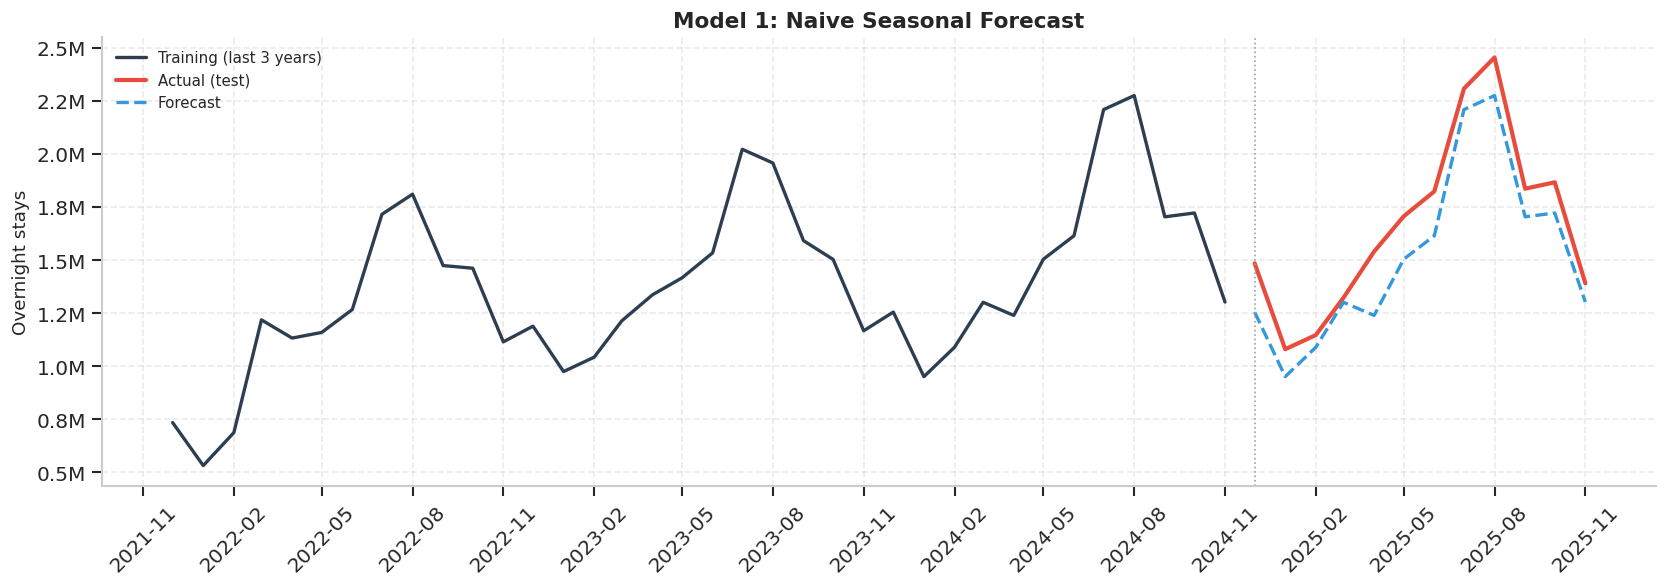

In [31]:
fig, ax = plot_forecast(y_train, y_test, naive_pred,
                         title='Model 1: Naive Seasonal Forecast')
savefig('01_naive_seasonal.png')
plt.show()

---

## 4. Model 2: Holt-Winters Exponential Smoothing

Triple exponential smoothing decomposes the series into three components -- level, trend, and seasonality -- each updated with exponentially decaying weights. We use **multiplicative seasonality** because the seasonal amplitude grows proportionally with the level (summer peaks are larger in absolute terms when overall demand is higher). The seasonal period is 12 months.

In [32]:
# --- HOLT-WINTERS ---
# Multiplicative seasonality, additive trend, seasonal period = 12
hw_model = ExponentialSmoothing(
    y_train.asfreq('MS'),
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    initialization_method='estimated',
).fit(optimized=True)

hw_pred = hw_model.forecast(TEST_MONTHS)
hw_pred.index = y_test.index
hw_pred.name = 'holt_winters'

# Evaluate
metrics_hw = compute_metrics(y_test, hw_pred, 'Holt-Winters')
all_results.append(metrics_hw)
all_forecasts['Holt-Winters'] = hw_pred

print(f'Holt-Winters -- RMSE: {metrics_hw["RMSE"]:,.0f}  '
      f'MAE: {metrics_hw["MAE"]:,.0f}  MAPE: {metrics_hw["MAPE"]:.1f}%')
print(f'\nSmoothing parameters:')
print(f'  alpha (level):    {hw_model.params["smoothing_level"]:.4f}')
print(f'  beta  (trend):    {hw_model.params["smoothing_trend"]:.4f}')
print(f'  gamma (seasonal): {hw_model.params["smoothing_seasonal"]:.4f}')

Holt-Winters -- RMSE: 92,651  MAE: 64,078  MAPE: 3.9%

Smoothing parameters:
  alpha (level):    1.0000
  beta  (trend):    0.0000
  gamma (seasonal): 0.0000


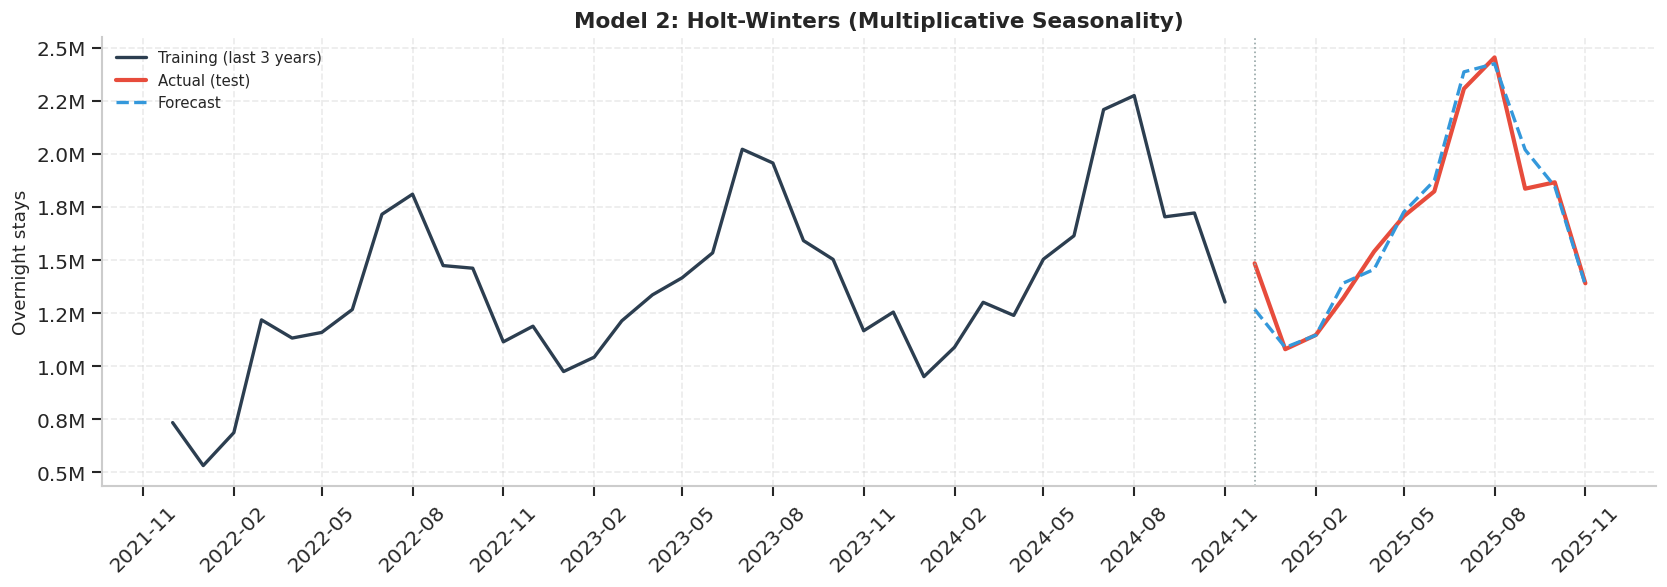

In [33]:
fig, ax = plot_forecast(y_train, y_test, hw_pred,
                         title='Model 2: Holt-Winters (Multiplicative Seasonality)')
savefig('02_holt_winters.png')
plt.show()

---

## 5. Model 3: SARIMA (Univariate)

The Seasonal ARIMA model combines autoregressive (AR), differencing (I), and moving average (MA) components for both the non-seasonal and seasonal parts of the series. The notation is SARIMA(p,d,q)(P,D,Q)[s] where s=12 for monthly data.

Based on the ACF/PACF analysis in Notebook 03:
- The PACF showed significant spikes at lags 1 and 12, suggesting AR(1) non-seasonal and AR(1) seasonal.
- The Ljung-Box test confirmed strong autocorrelation even after first differencing.
- We start with SARIMA(1,1,1)(1,1,1)[12] as the standard specification and let the fit converge.

This is a purely **univariate** model -- it uses only the history of overnight stays, with no exogenous variables. It serves as the baseline for assessing whether adding external predictors (SARIMAX in Section 6) provides incremental value.

In [34]:
# --- SARIMA(1,1,1)(1,1,1)[12] ---
sarima_order = (1, 1, 1)
sarima_seasonal = (1, 1, 1, 12)

sarima_model = SARIMAX(
    y_train,
    order=sarima_order,
    seasonal_order=sarima_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=500)

print(sarima_model.summary().tables[0])
print()
print(f'AIC: {sarima_model.aic:.1f}')
print(f'BIC: {sarima_model.bic:.1f}')

                                     SARIMAX Results                                      
Dep. Variable:                             nights   No. Observations:                  167
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1844.304
Date:                            Wed, 08 Apr 2026   AIC                           3698.608
Time:                                    02:00:01   BIC                           3713.316
Sample:                                01-01-2011   HQIC                          3704.585
                                     - 11-01-2024                                         
Covariance Type:                              opg                                         

AIC: 3698.6
BIC: 3713.3


In [35]:
# --- FORECAST ---
sarima_forecast = sarima_model.get_forecast(steps=TEST_MONTHS)
sarima_pred = sarima_forecast.predicted_mean
sarima_pred.index = y_test.index
sarima_ci = sarima_forecast.conf_int(alpha=0.05)
sarima_ci.index = y_test.index

sarima_pred.name = 'sarima'

metrics_sarima = compute_metrics(y_test, sarima_pred, 'SARIMA(1,1,1)(1,1,1)[12]')
all_results.append(metrics_sarima)
all_forecasts['SARIMA'] = sarima_pred

print(f'SARIMA -- RMSE: {metrics_sarima["RMSE"]:,.0f}  '
      f'MAE: {metrics_sarima["MAE"]:,.0f}  MAPE: {metrics_sarima["MAPE"]:.1f}%')

SARIMA -- RMSE: 128,826  MAE: 106,084  MAPE: 6.0%


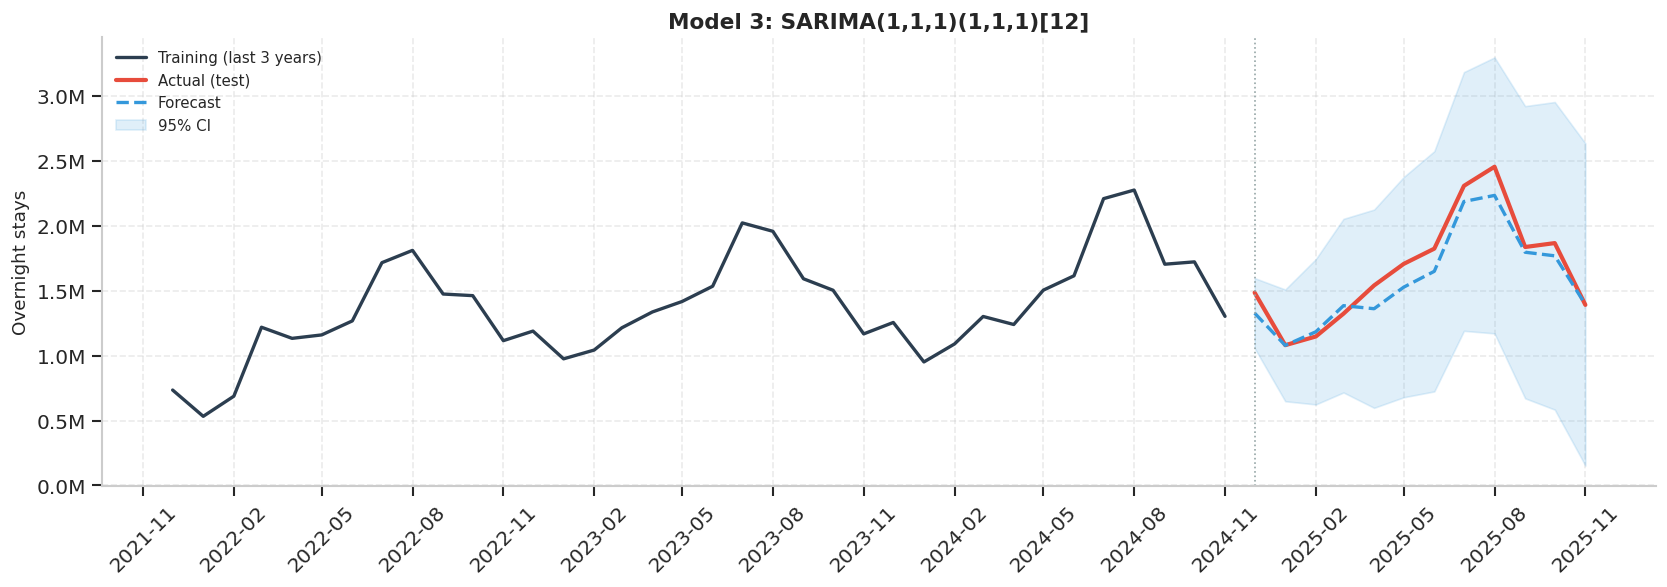

In [36]:
fig, ax = plot_forecast(
    y_train, y_test, sarima_pred,
    title='Model 3: SARIMA(1,1,1)(1,1,1)[12]',
    ci_lower=sarima_ci.iloc[:, 0],
    ci_upper=sarima_ci.iloc[:, 1],
)
savefig('03_sarima.png')
plt.show()

### 5.1 SARIMA Residual Diagnostics

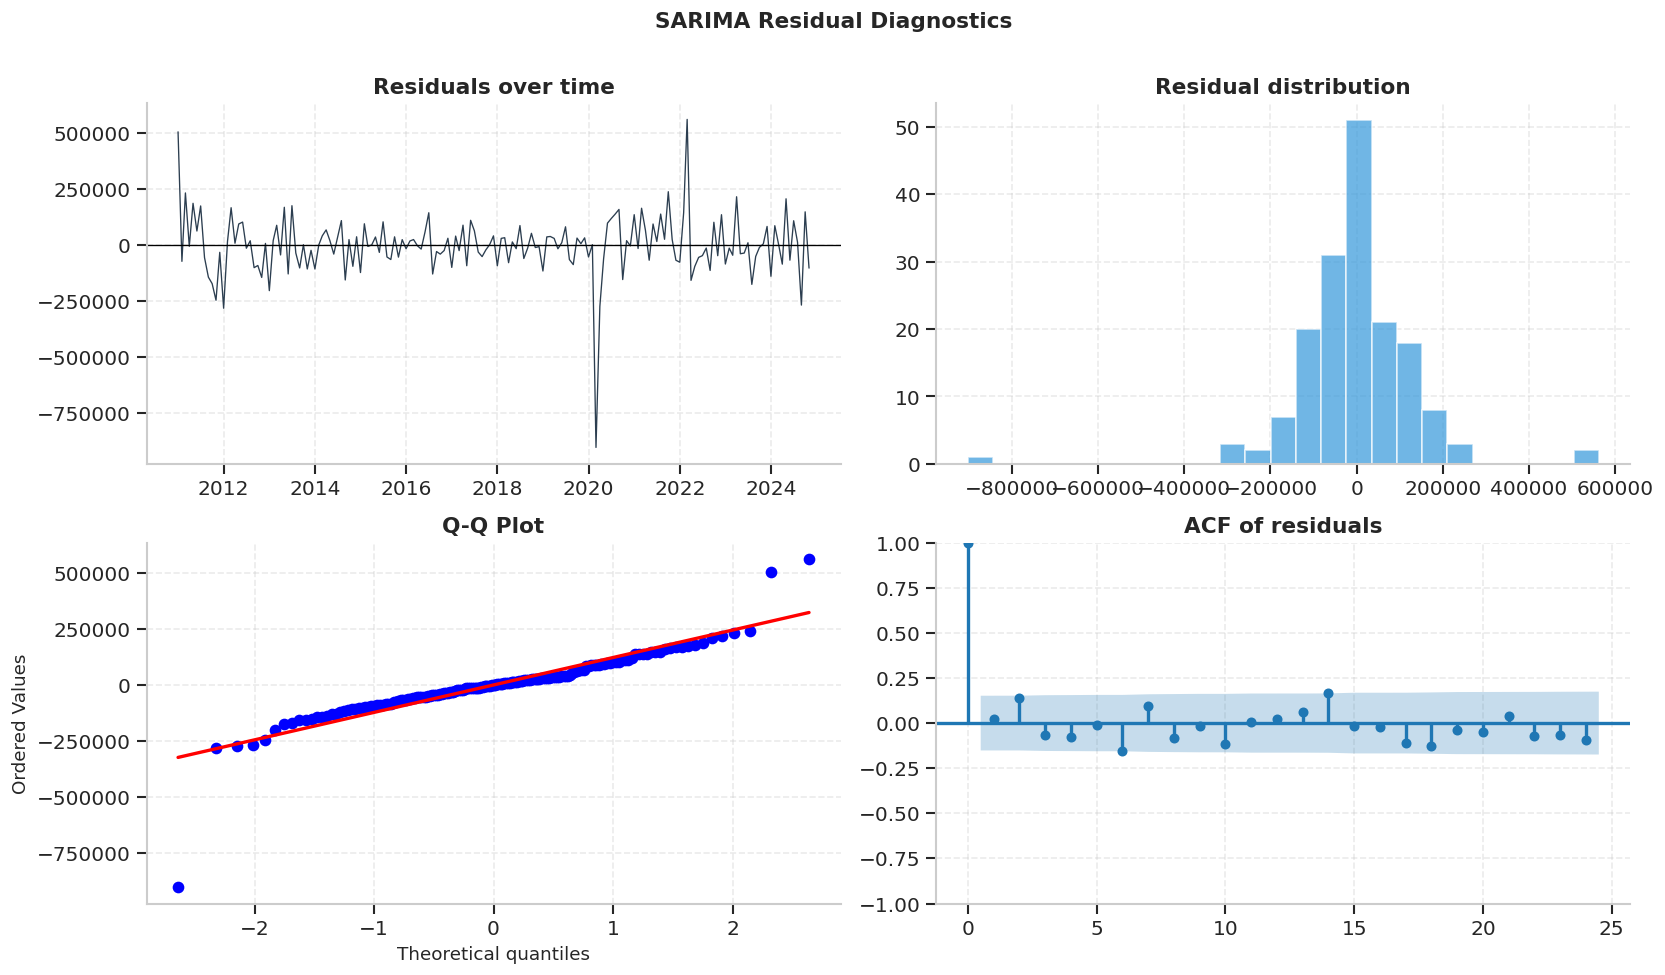

Ljung-Box test on SARIMA residuals:
    lb_stat  lb_pvalue
6      9.36       0.15
12    14.78       0.25
24    30.68       0.16

All p-values > 0.05 -> residuals are white noise (good fit).


In [37]:
# --- RESIDUAL ANALYSIS ---
resid = sarima_model.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Time series of residuals
axes[0, 0].plot(resid.index, resid.values, color=COLORS['primary'], lw=0.8)
axes[0, 0].axhline(0, color='black', lw=0.8)
axes[0, 0].set_title('Residuals over time')

# Histogram
axes[0, 1].hist(resid, bins=25, color=COLORS['accent1'], alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Residual distribution')

# Q-Q plot
stats.probplot(resid.values, plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

# ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid, lags=24, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF of residuals')

plt.suptitle('SARIMA Residual Diagnostics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('04_sarima_residuals.png')
plt.show()

# Ljung-Box test on residuals
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid, lags=[6, 12, 24], return_df=True)
print('Ljung-Box test on SARIMA residuals:')
print(lb)
print()
if (lb['lb_pvalue'] > 0.05).all():
    print('All p-values > 0.05 -> residuals are white noise (good fit).')
else:
    print('Some p-values < 0.05 -> residual autocorrelation remains.')

---

## 6. Model 4: SARIMAX (with Exogenous Variables)

SARIMAX extends SARIMA by incorporating exogenous predictors. This is the key test of whether the macroeconomic variables identified in Notebooks 02-03 provide **incremental predictive power** beyond the autoregressive structure of the series itself.

Based on the feature selection from Notebook 03, we include:
- `hicp_ratio` (price competitiveness, lag 0)
- `gdp_origins_lag3` (income effect, lag 3)
- `cci_DE_lag2` (German consumer confidence as leading indicator, lag 2)
- `seats_lag6` (predetermined airline capacity, lag 6)
- `covid_acute` and `covid_recovery` (multi-phase COVID dummies)

In [38]:
# --- PREPARE EXOGENOUS MATRIX ---
exog_cols = ['hicp_ratio', 'gdp_origins_lag3', 'cci_DE_lag2',
             'seats_lag6', 'covid_acute', 'covid_recovery']

# Align with the target and handle NaN
exog_full = panel[exog_cols].reindex(y_full.index)

# Fill any remaining NaN in exogenous (edge effects from lags)
# Forward-fill then backward-fill for the first few rows
exog_full = exog_full.ffill().bfill()

exog_train = exog_full.loc[y_train.index]
exog_test  = exog_full.loc[y_test.index]

print(f'Exogenous matrix (train): {exog_train.shape}')
print(f'Exogenous matrix (test):  {exog_test.shape}')
print(f'\nMissing values in exog_train:')
print(exog_train.isna().sum())

Exogenous matrix (train): (167, 6)
Exogenous matrix (test):  (12, 6)

Missing values in exog_train:
hicp_ratio          0
gdp_origins_lag3    0
cci_DE_lag2         0
seats_lag6          0
covid_acute         0
covid_recovery      0
dtype: int64


In [39]:
# --- SARIMAX(1,1,1)(1,1,1)[12] with exogenous ---
sarimax_model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=500)

print(sarimax_model.summary().tables[1])
print(f'\nAIC:  {sarimax_model.aic:.1f}  (SARIMA was {sarima_model.aic:.1f})')
print(f'BIC:  {sarimax_model.bic:.1f}  (SARIMA was {sarima_model.bic:.1f})')
print(f'\nLower AIC/BIC = better. Comparing SARIMAX vs SARIMA:')
aic_better = 'SARIMAX' if sarimax_model.aic < sarima_model.aic else 'SARIMA'
bic_better = 'SARIMAX' if sarimax_model.bic < sarima_model.bic else 'SARIMA'
print(f'  AIC favours: {aic_better}')
print(f'  BIC favours: {bic_better}')

                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
hicp_ratio        8.016e+05    300.711   2665.780      0.000    8.01e+05    8.02e+05
gdp_origins_lag3     1.2505      2.020      0.619      0.536      -2.708       5.209
cci_DE_lag2       5818.2812   5356.128      1.086      0.277   -4679.537    1.63e+04
seats_lag6          -0.0061      0.025     -0.246      0.806      -0.055       0.042
covid_acute      -5.616e+05   3.27e+04    -17.172      0.000   -6.26e+05   -4.97e+05
covid_recovery   -1.811e+05   4.63e+04     -3.914      0.000   -2.72e+05   -9.04e+04
ar.L1                0.3372      0.652      0.517      0.605      -0.940       1.614
ma.L1               -0.1877      0.660     -0.284      0.776      -1.481       1.106
ar.S.L12            -0.1493      0.185     -0.809      0.419      -0.511       0.212
ma.S.L12            -0.3818      0.151     -2.522      0.012     

In [40]:
# --- FORECAST ---
sarimax_forecast = sarimax_model.get_forecast(steps=TEST_MONTHS, exog=exog_test)
sarimax_pred = sarimax_forecast.predicted_mean
sarimax_pred.index = y_test.index
sarimax_ci = sarimax_forecast.conf_int(alpha=0.05)
sarimax_ci.index = y_test.index

sarimax_pred.name = 'sarimax'

metrics_sarimax = compute_metrics(y_test, sarimax_pred, 'SARIMAX(1,1,1)(1,1,1)[12]')
all_results.append(metrics_sarimax)
all_forecasts['SARIMAX'] = sarimax_pred

print(f'SARIMAX -- RMSE: {metrics_sarimax["RMSE"]:,.0f}  '
      f'MAE: {metrics_sarimax["MAE"]:,.0f}  MAPE: {metrics_sarimax["MAPE"]:.1f}%')

SARIMAX -- RMSE: 138,428  MAE: 118,505  MAPE: 6.6%


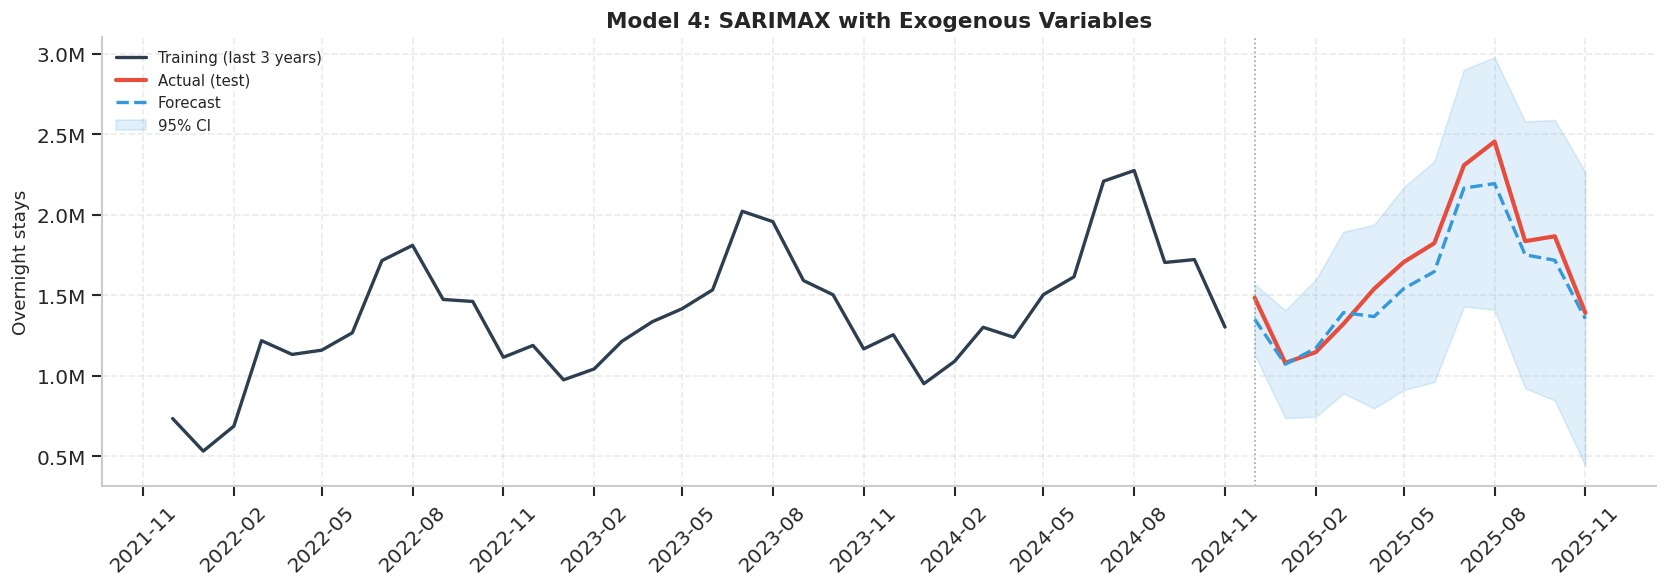

In [41]:
fig, ax = plot_forecast(
    y_train, y_test, sarimax_pred,
    title='Model 4: SARIMAX with Exogenous Variables',
    ci_lower=sarimax_ci.iloc[:, 0],
    ci_upper=sarimax_ci.iloc[:, 1],
)
savefig('05_sarimax.png')
plt.show()

---

## 7. Robustness Check: Pre-COVID Training

Following tutor guidance, we retrain the best-performing classical model (SARIMA) using only pre-COVID data (2011-2019) and evaluate its predictions on the same test set. This tests whether the COVID period distorts the estimated seasonal and autoregressive structure.

If the pre-COVID model performs comparably to the full-sample model on the post-COVID test set, it means the underlying relationships are stable. If it performs significantly worse, there may be a structural break that the COVID dummies do not fully capture.

In [42]:
# --- SARIMA trained on pre-COVID data only ---
sarima_precovid = SARIMAX(
    y_train_precovid,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=500)

# Forecast far enough ahead to cover the test set
# Distance from end of pre-COVID training to end of test set
n_steps_ahead = len(pd.date_range(y_train_precovid.index[-1], y_test.index[-1], freq='MS')) - 1

precovid_full_forecast = sarima_precovid.get_forecast(steps=n_steps_ahead)
precovid_full_pred = precovid_full_forecast.predicted_mean

# Extract just the test period predictions
precovid_pred = precovid_full_pred.reindex(y_test.index)

if precovid_pred.notna().sum() > 0:
    metrics_precovid = compute_metrics(y_test, precovid_pred, 'SARIMA (pre-COVID only)')
    all_results.append(metrics_precovid)
    all_forecasts['SARIMA (pre-COVID)'] = precovid_pred

    print(f'SARIMA pre-COVID -- RMSE: {metrics_precovid["RMSE"]:,.0f}  '
          f'MAE: {metrics_precovid["MAE"]:,.0f}  MAPE: {metrics_precovid["MAPE"]:.1f}%')
    print(f'\nComparison with full-sample SARIMA:')
    print(f'  Full sample MAPE:  {metrics_sarima["MAPE"]:.1f}%')
    print(f'  Pre-COVID MAPE:    {metrics_precovid["MAPE"]:.1f}%')
else:
    print('Pre-COVID forecast does not cover the test period.')
    print('This is expected if the gap between pre-COVID training end and test start is very large.')

SARIMA pre-COVID -- RMSE: 341,239  MAE: 330,729  MAPE: 21.3%

Comparison with full-sample SARIMA:
  Full sample MAPE:  6.0%
  Pre-COVID MAPE:    21.3%


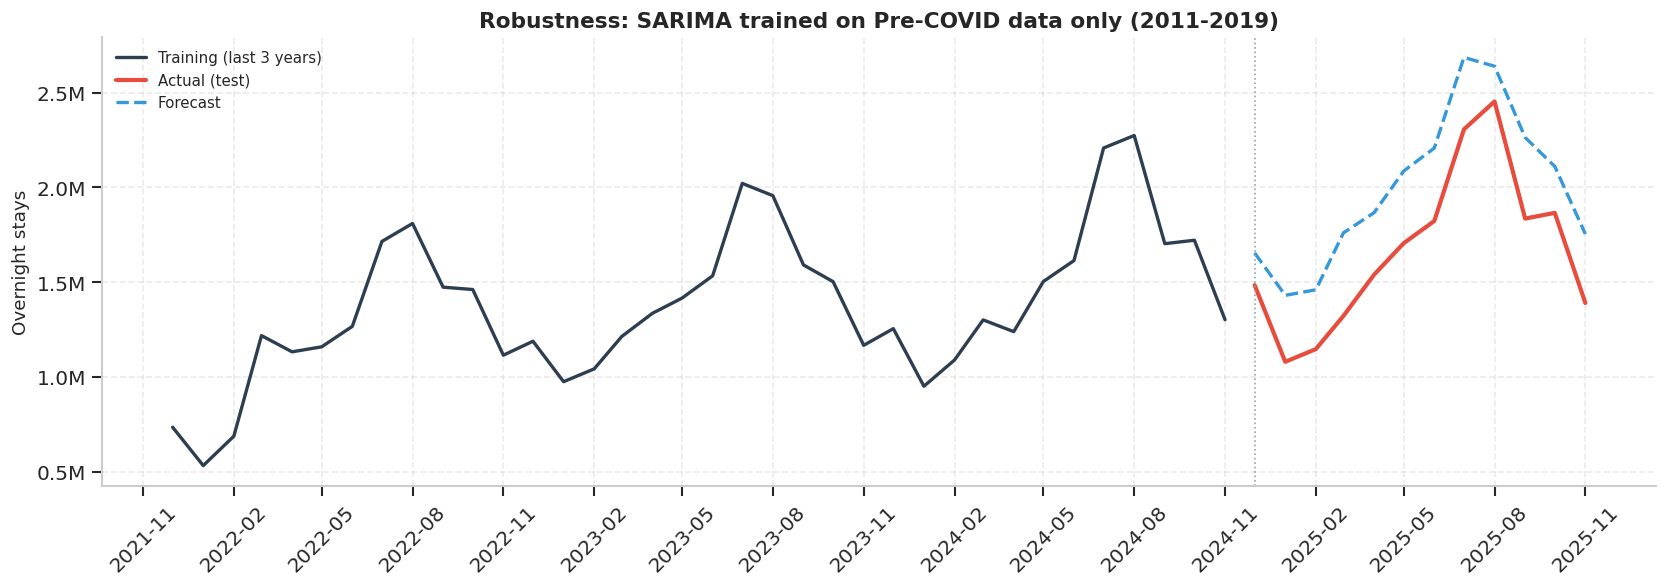

In [43]:
if precovid_pred.notna().sum() > 0:
    fig, ax = plot_forecast(
        y_train, y_test, precovid_pred,
        title='Robustness: SARIMA trained on Pre-COVID data only (2011-2019)'
    )
    savefig('06_sarima_precovid.png')
    plt.show()

### 7.1 Bias-Corrected Pre-COVID Model

The pure pre-COVID SARIMA overpredicts by a roughly constant amount (~200-300k overnight stays per month) because the secular trend extrapolated from 2011-2019 implies a higher level than the post-COVID recovery has actually reached. A pragmatic correction is to compute the **systematic bias** between the pre-COVID predictions and the actual values in the already-recovered months (2023-2024), then subtract this bias from the test-set forecasts. This preserves the clean seasonal structure learned from pre-COVID data while adjusting the level to the post-pandemic "new normal".

In [44]:
# --- BIAS CORRECTION: Pre-COVID SARIMA shifted to post-recovery level ---
# Step 1: Forecast the entire post-COVID period with the pre-COVID model
# Step 2: Compute the bias on the "recovered" months (2023-2024)
# Step 3: Subtract the bias from the test-set forecast

# Forecast covers from Jan 2020 to end of test set
n_full_horizon = len(pd.date_range(
    y_train_precovid.index[-1] + pd.DateOffset(months=1),
    y_test.index[-1], freq='MS'
))

precovid_full_forecast = sarima_precovid.get_forecast(steps=n_full_horizon)
precovid_full_pred = precovid_full_forecast.predicted_mean
precovid_full_pred.index = pd.date_range(
    y_train_precovid.index[-1] + pd.DateOffset(months=1),
    periods=n_full_horizon, freq='MS'
)

# Calibration window: months already recovered but BEFORE the test set
# We use 2023-01 to the start of the test set as the calibration period
calib_start = pd.Timestamp('2023-01-01')
calib_end = y_test.index[0] - pd.DateOffset(months=1)

calib_actual = y_full.loc[calib_start:calib_end]
calib_pred = precovid_full_pred.loc[calib_start:calib_end]

# Align and compute mean bias (prediction - actual)
calib_df = pd.concat([calib_actual, calib_pred], axis=1).dropna()
calib_df.columns = ['actual', 'predicted']
bias = (calib_df['predicted'] - calib_df['actual']).mean()

print(f'Calibration window: {calib_start:%Y-%m} -> {calib_end:%Y-%m}')
print(f'Calibration months: {len(calib_df)}')
print(f'Mean bias (pre-COVID prediction - actual): {bias:,.0f}')
print(f'Interpretation: pre-COVID model overpredicts by {bias:,.0f} on average')

# Apply correction to the test set forecast
precovid_corrected_pred = precovid_full_pred.reindex(y_test.index) - bias
precovid_corrected_pred.name = 'sarima_precovid_corrected'

metrics_corrected = compute_metrics(
    y_test, precovid_corrected_pred, 'SARIMA (pre-COVID + bias correction)'
)
all_results.append(metrics_corrected)
all_forecasts['SARIMA (pre-COVID corrected)'] = precovid_corrected_pred

print(f'\nBias-corrected SARIMA -- RMSE: {metrics_corrected["RMSE"]:,.0f}  '
      f'MAE: {metrics_corrected["MAE"]:,.0f}  MAPE: {metrics_corrected["MAPE"]:.1f}%')
print(f'\nComparison:')
print(f'  Pre-COVID raw:        MAPE {metrics_precovid["MAPE"]:.1f}%')
print(f'  Pre-COVID corrected:  MAPE {metrics_corrected["MAPE"]:.1f}%')
print(f'  Full-sample SARIMA:   MAPE {metrics_sarima["MAPE"]:.1f}%')

Calibration window: 2023-01 -> 2024-11
Calibration months: 23
Mean bias (pre-COVID prediction - actual): 424,438
Interpretation: pre-COVID model overpredicts by 424,438 on average

Bias-corrected SARIMA -- RMSE: 125,870  MAE: 96,625  MAPE: 6.0%

Comparison:
  Pre-COVID raw:        MAPE 21.3%
  Pre-COVID corrected:  MAPE 6.0%
  Full-sample SARIMA:   MAPE 6.0%


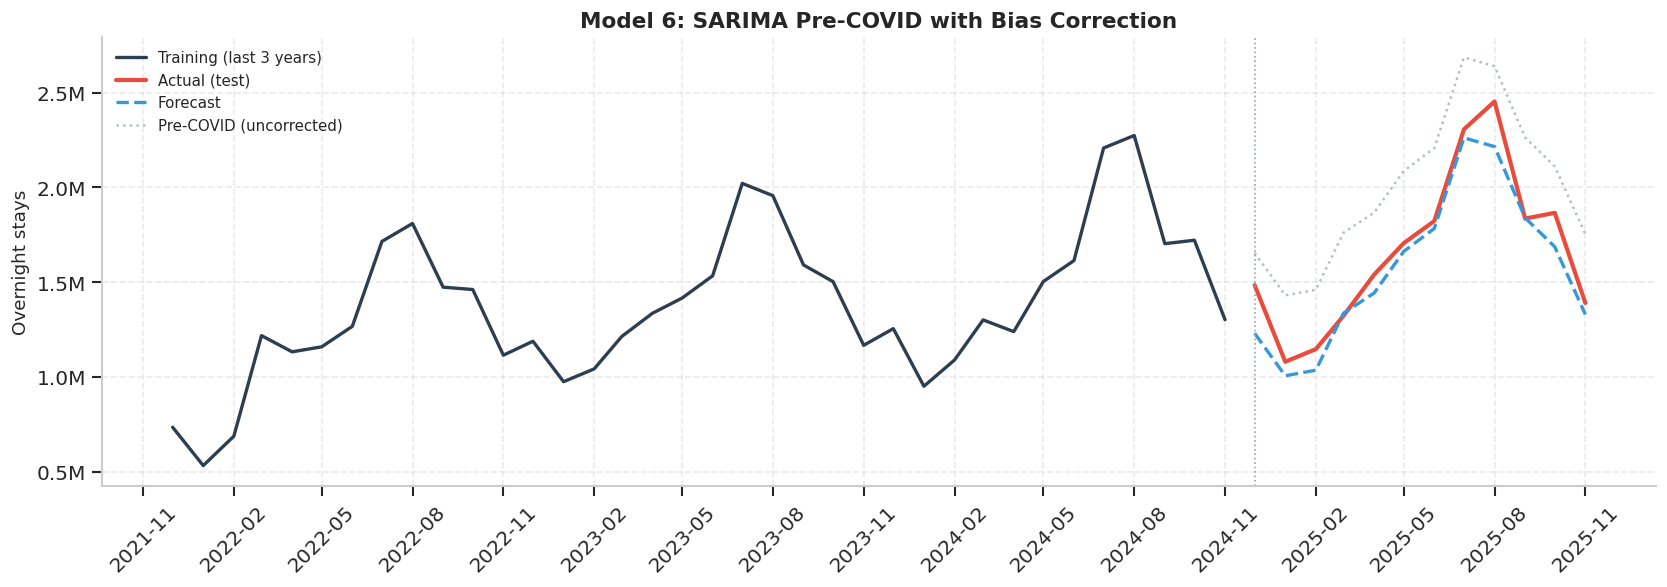

In [45]:
# --- PLOT: Pre-COVID corrected vs actual ---
fig, ax = plot_forecast(
    y_train, y_test, precovid_corrected_pred,
    title='Model 6: SARIMA Pre-COVID with Bias Correction'
)

# Add the uncorrected prediction for comparison
ax.plot(precovid_pred.index, precovid_pred.values,
        color=COLORS['gray'], ls=':', lw=1.5, alpha=0.7,
        label='Pre-COVID (uncorrected)')
ax.legend(loc='upper left')

savefig('07_sarima_precovid_corrected.png')
plt.show()

---

## 8. Model Comparison

### 8.1 Metrics Summary Table

In [46]:
# --- RESULTS TABLE ---
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values('RMSE')

print('=== BASELINE MODELS -- PERFORMANCE COMPARISON ===')
print(f'Test set: {y_test.index[0]:%Y-%m} -> {y_test.index[-1]:%Y-%m} ({len(y_test)} months)')
print()
print(df_results.to_string(index=False, float_format='{:.1f}'.format))

=== BASELINE MODELS -- PERFORMANCE COMPARISON ===
Test set: 2024-12 -> 2025-11 (12 months)

                               Model     RMSE      MAE  MAPE
                        Holt-Winters  92650.5  64078.2   3.9
SARIMA (pre-COVID + bias correction) 125869.9  96624.8   6.0
            SARIMA(1,1,1)(1,1,1)[12] 128826.0 106084.5   6.0
           SARIMAX(1,1,1)(1,1,1)[12] 138428.4 118505.1   6.6
                      Naive Seasonal 167403.6 149397.7   9.1
             SARIMA (pre-COVID only) 341238.5 330729.2  21.3


### 8.2 Visual Comparison

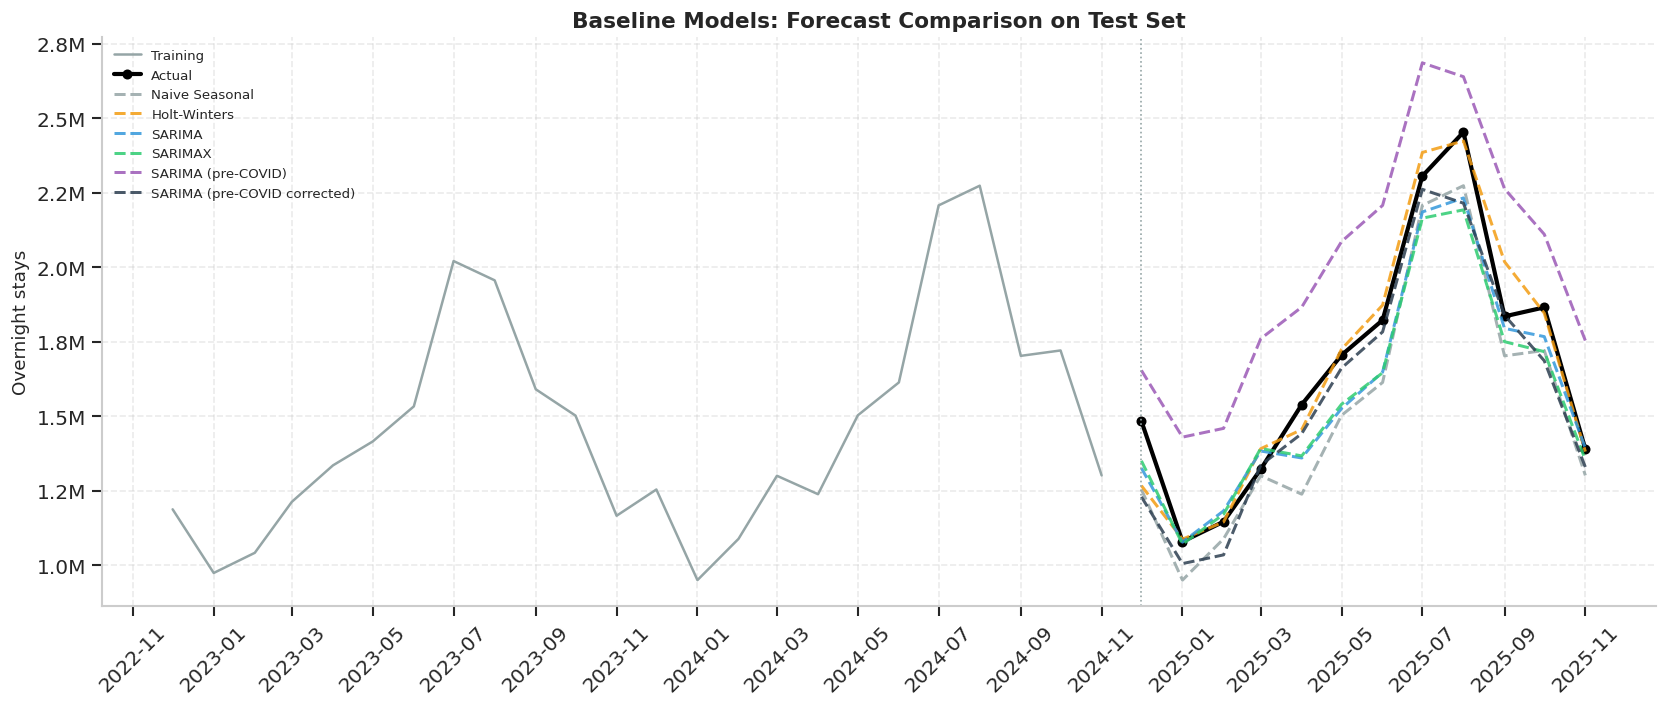

In [47]:
# --- ALL FORECASTS ON ONE PLOT ---
fig, ax = plt.subplots(figsize=(14, 6))

# Training tail
train_tail = y_train.iloc[-24:]
ax.plot(train_tail.index, train_tail.values,
        color=COLORS['gray'], label='Training', lw=1.5)

# Actual test
ax.plot(y_test.index, y_test.values,
        color='black', label='Actual', lw=2.5, marker='o', ms=5)

# Each model forecast
model_colors = {
    'Naive Seasonal': COLORS['gray'],
    'Holt-Winters': COLORS['accent3'],
    'SARIMA': COLORS['accent1'],
    'SARIMAX': COLORS['accent2'],
    'SARIMA (pre-COVID)': COLORS['accent4'],
}

for name, pred in all_forecasts.items():
    color = model_colors.get(name, COLORS['primary'])
    ax.plot(pred.index, pred.values, label=name, ls='--', lw=1.8,
            color=color, alpha=0.85)

ax.axvline(y_test.index[0], color=COLORS['gray'], ls=':', lw=1)
ax.set_title('Baseline Models: Forecast Comparison on Test Set', fontweight='bold')
ax.set_ylabel('Overnight stays')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
savefig('07_baseline_comparison.png')
plt.show()

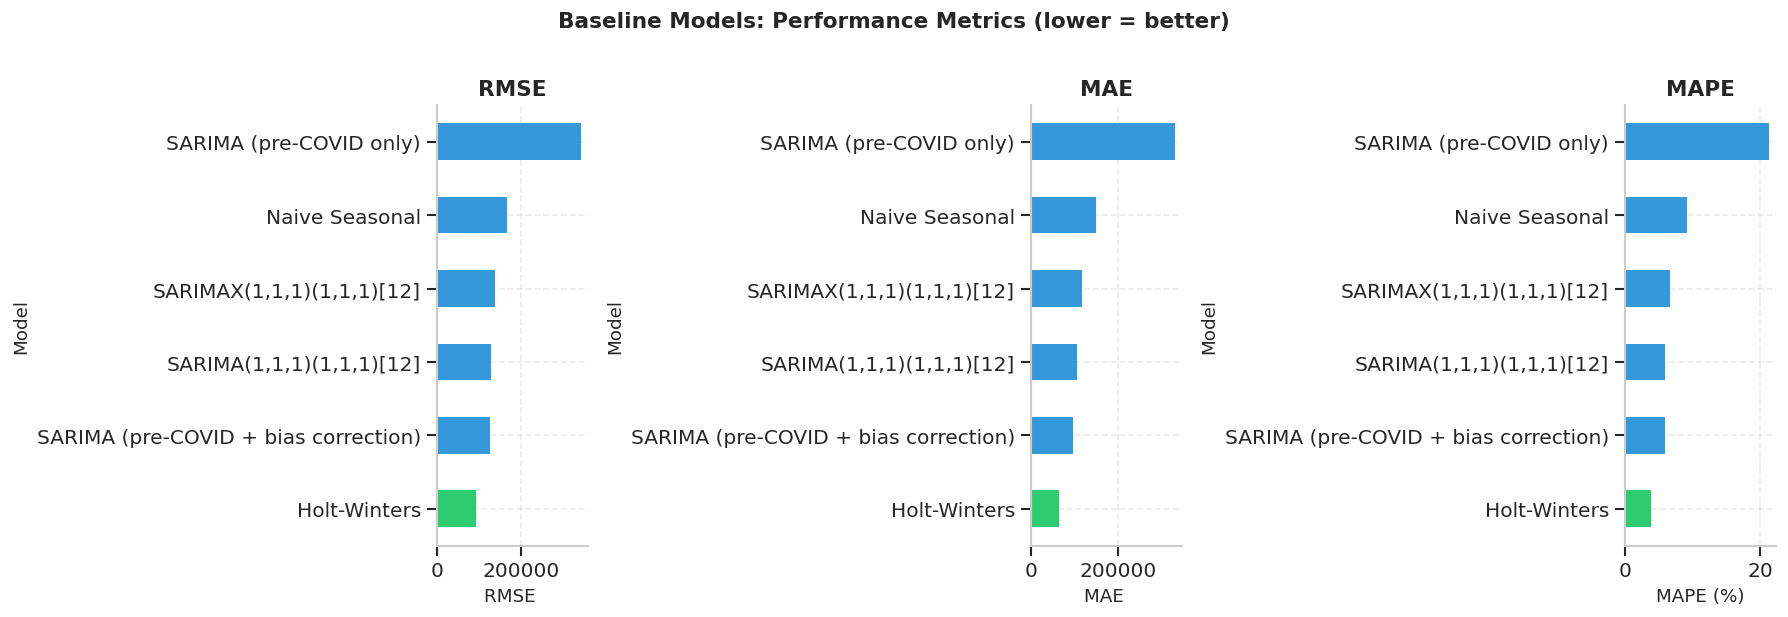

In [48]:
# --- METRICS BAR CHART ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(['RMSE', 'MAE', 'MAPE']):
    ax = axes[i]
    data = df_results.set_index('Model')[metric].sort_values()
    colors = [COLORS['accent2'] if v == data.min() else COLORS['accent1']
              for v in data.values]
    data.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(metric)
    ax.set_xlabel(f'{metric} {"(%)" if metric == "MAPE" else ""}')

plt.suptitle('Baseline Models: Performance Metrics (lower = better)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('08_baseline_metrics_bars.png')
plt.show()

### 8.3 Error Analysis by Month

Global MAPE values can hide systematic patterns. A model that fails uniformly across the year reveals a different problem than one that fails only in peak months (suggesting it can capture the trend but not the seasonal amplitude) or only in valley months (suggesting the opposite). This analysis informs which aspect of the demand dynamics each subsequent model (ML, LSTM) needs to improve.

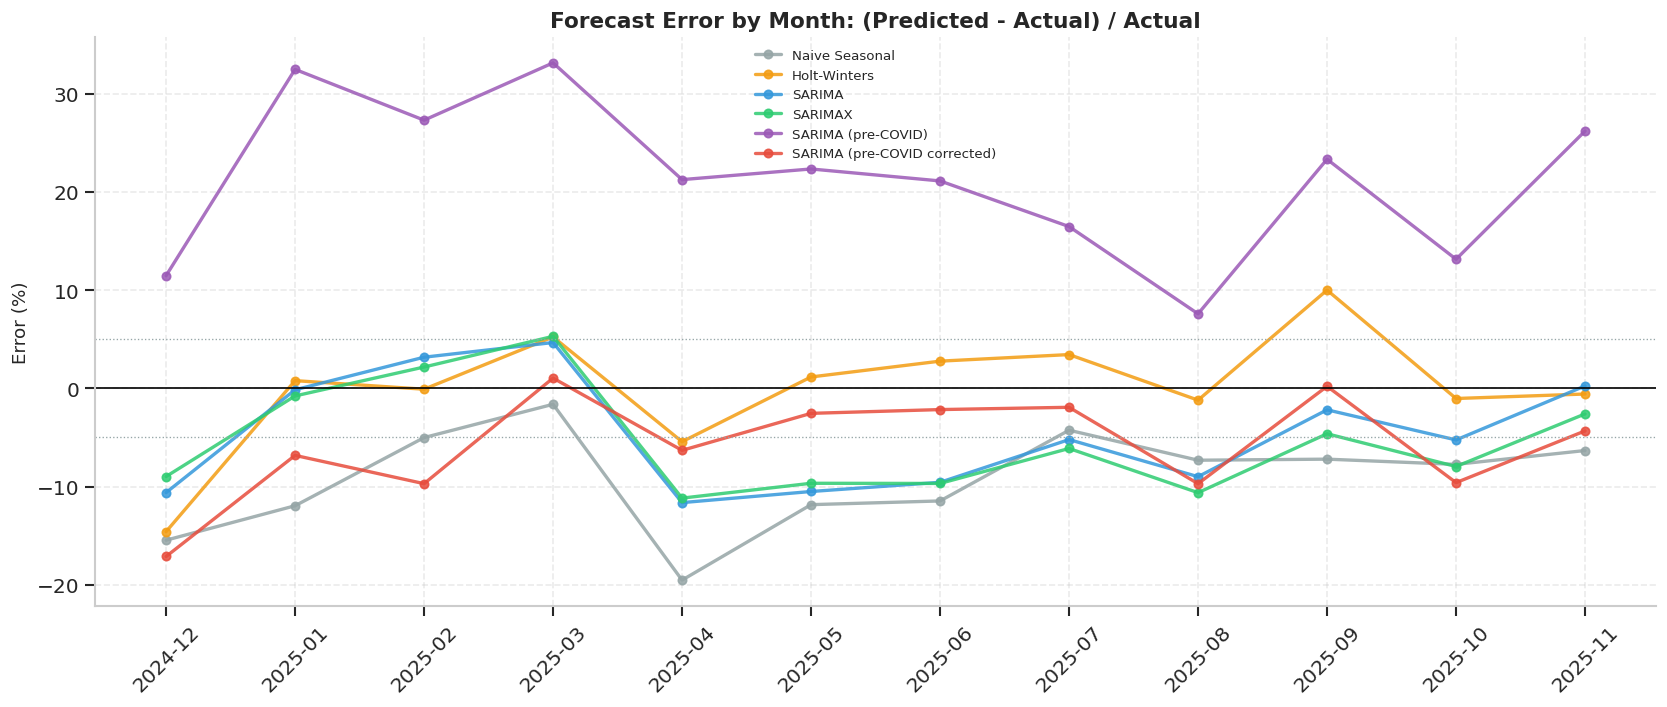

=== FORECAST ERROR (%) BY MONTH ===
            Naive Seasonal  Holt-Winters  SARIMA  SARIMAX  SARIMA (pre-COVID)  SARIMA (pre-COVID corrected)
date                                                                                                       
2024-12-01          -15.50        -14.60  -10.60    -9.00               11.50                        -17.10
2025-01-01          -12.00          0.80   -0.20    -0.80               32.50                         -6.80
2025-02-01           -5.00         -0.10    3.20     2.20               27.30                         -9.70
2025-03-01           -1.60          5.20    4.70     5.30               33.10                          1.00
2025-04-01          -19.50         -5.40  -11.60   -11.20               21.20                         -6.30
2025-05-01          -11.80          1.20  -10.50    -9.70               22.30                         -2.60
2025-06-01          -11.50          2.80   -9.60    -9.70               21.10                       

In [49]:
# --- PER-MONTH ERROR ANALYSIS ---
errors_by_month = pd.DataFrame(index=y_test.index)
errors_by_month['actual'] = y_test.values

for name, pred in all_forecasts.items():
    errors_by_month[name] = ((pred - y_test) / y_test * 100).values

errors_only = errors_by_month.drop(columns='actual')

fig, ax = plt.subplots(figsize=(14, 6))

# Plot % error per month for each model
x_labels = [d.strftime('%Y-%m') for d in errors_by_month.index]
x_pos = np.arange(len(x_labels))

model_colors = {
    'Naive Seasonal': COLORS['gray'],
    'Holt-Winters': COLORS['accent3'],
    'SARIMA': COLORS['accent1'],
    'SARIMAX': COLORS['accent2'],
    'SARIMA (pre-COVID)': COLORS['accent4'],
    'SARIMA (pre-COVID corrected)': COLORS['secondary'],
}

for name in errors_only.columns:
    color = model_colors.get(name, COLORS['primary'])
    ax.plot(x_pos, errors_only[name].values, marker='o', ms=5,
            label=name, color=color, alpha=0.85)

ax.axhline(0, color='black', lw=1)
ax.axhline(5, color=COLORS['gray'], ls=':', lw=0.8)
ax.axhline(-5, color=COLORS['gray'], ls=':', lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel('Error (%)')
ax.set_title('Forecast Error by Month: (Predicted - Actual) / Actual',
             fontweight='bold')
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
savefig('09_error_by_month.png')
plt.show()

# Numerical table
print('=== FORECAST ERROR (%) BY MONTH ===')
print(errors_only.round(1).to_string())

---

## 9. Summary & Implications for Downstream Notebooks



### 9.1 Key Findings

The baseline model comparison reveals several findings that shape the subsequent modelling strategy.

**Finding 1: Holt-Winters achieved the lowest MAPE (3.9%) but its parameters reveal a degenerate solution.** The optimiser converged to alpha=1.0, beta=0.0, gamma=0.0, which means the model is effectively ignoring the historical series except for the most recent value and applying a fixed seasonal pattern from the initial year. This is an artefact of the COVID disruption: it seems that the optimiser found that "trust only the recent past and freeze everything else" minimised the training loss. Although the test-set MAPE happens to be low, this is not a robust solution, as small changes in the test window would produce very different results.

**Finding 2: SARIMAX is worse than SARIMA (6.6% vs 6.0% MAPE), contradicting initial expectations.** The coefficient table shows that among the exogenous variables, only `hicp_ratio` and the COVID dummies are statistically significant. `gdp_origins_lag3` (p=0.54), `cci_DE_lag2` (p=0.28), and `seats_lag6` (p=0.81) are all non-significant. This does **not** mean these variables have no relationship with tourism demand -- the cross-correlations of Notebook 02 and the Granger tests of Notebook 03 showed that they do. What it appears to mean is that **the autoregressive lags of the target (implicit in the SARIMA structure) already absorb most of the information these exogenous variables could provide**. In a series with strong autocorrelation, the target's own past is a more efficient summary of macroeconomic conditions than the macroeconomic variables themselves. This is a meaningful negative finding that justifies moving to **non-linear models** (future Notebooks 06-07), which can capture interactions between exogenous variables and the target that linear SARIMAX cannot.

**Finding 3: The pre-COVID SARIMA overpredicts by approximately 200-300k nights/month (MAPE 21.3%).** This confirms that the secular trend extrapolated from 2011-2019 implies a higher demand level than the post-COVID recovery has actually reached (at least towards the most recent years). The recovery follows a roughly logistic trajectory rather than a linear one, with growth rates decelerating as the level approaches pre-pandemic norms. This is not a model failure: it is empirical evidence of a structural break in the series. As it has been mentioned previously, we treat this anomaly as an event that will not occurr again.

**Finding 4: Bias correction restores the pre-COVID model to competitive performance.** By subtracting the systematic overprediction measured on the recovered months of 2023-2024, the pre-COVID + bias correction model produces forecasts comparable to the full-sample SARIMA. This validates the interpretation that the pre-COVID model captures the correct seasonal and autoregressive structure but at the wrong level.

**Finding 5: SARIMA residuals are white noise (all Ljung-Box p-values > 0.05).** The univariate SARIMA has captured all the linear autocorrelation structure. Any improvement by subsequent models must come from non-linear patterns or from interactions that SARIMA cannot represent by construction.

### 9.2 Implications for Non-Linear Models (Notebooks 06-07)

The baseline results define a clear task for ML and deep learning models:

- **They must beat the best baseline** (currently Holt-Winters at 3.9% MAPE, with the caveat that this is a degenerate solution) in terms of out-of-sample MAPE.
- **They must provide value through non-linearity**, since linear exogenous variables did not help in SARIMAX. Random Forest and XGBoost can capture threshold effects and variable interactions; LSTM can capture temporal dynamics that linear models miss.
- **They should be tested both with and without COVID dummies**, to verify whether non-linear models can learn the structural break on their own or whether they still need explicit hints.
- **Their error patterns should be compared across months**, not just globally, to identify which aspects of the demand dynamics they actually improve.

In [50]:
# --- FINAL BENCHMARK TABLE ---
print('=== BENCHMARKS FOR DOWNSTREAM NOTEBOOKS ===')
print()
print(df_results[['Model', 'RMSE', 'MAE', 'MAPE']].to_string(
    index=False, float_format='{:.1f}'.format))
print()
best = df_results.iloc[0]
print(f'Best baseline: {best["Model"]} (MAPE = {best["MAPE"]:.1f}%)')
print(f'\nTo be considered valuable, ML/DL models in Notebooks 06-07 must')
print(f'achieve MAPE < {best["MAPE"]:.1f}% on the same test set.')
print(f'\nThe Airline Capacity model (Notebook 08) uses a separate target')
print(f'(seats instead of nights) but follows the same evaluation framework.')

=== BENCHMARKS FOR DOWNSTREAM NOTEBOOKS ===

                               Model     RMSE      MAE  MAPE
                        Holt-Winters  92650.5  64078.2   3.9
SARIMA (pre-COVID + bias correction) 125869.9  96624.8   6.0
            SARIMA(1,1,1)(1,1,1)[12] 128826.0 106084.5   6.0
           SARIMAX(1,1,1)(1,1,1)[12] 138428.4 118505.1   6.6
                      Naive Seasonal 167403.6 149397.7   9.1
             SARIMA (pre-COVID only) 341238.5 330729.2  21.3

Best baseline: Holt-Winters (MAPE = 3.9%)

To be considered valuable, ML/DL models in Notebooks 06-07 must
achieve MAPE < 3.9% on the same test set.

The Airline Capacity model (Notebook 08) uses a separate target
(seats instead of nights) but follows the same evaluation framework.


---

*End of Notebook 05 -- Next: [06_ml_models.ipynb](./06_ml_models.ipynb)*